<a href="https://colab.research.google.com/github/BTrifonov/BTrifonov/blob/main/snn_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install required packages

In [1]:
!pip install snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 2.8 MB/s eta 0:00:00


In [14]:
# imports
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np

# Reproducibility
torch.manual_seed(0)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [10]:
#@title Plotting Settings
def plot_cur_mem_spk(cur, mem, spk, thr_line=False, vline=False, title=False, ylim_max1=1.25, ylim_max2=1.25):
  # Generate Plots
  fig, ax = plt.subplots(3, figsize=(8,6), sharex=True,
                        gridspec_kw = {'height_ratios': [1, 1, 0.4]})

  # Plot input current
  ax[0].plot(cur, c="tab:orange")
  ax[0].set_ylim([0, ylim_max1])
  ax[0].set_xlim([0, 200])
  ax[0].set_ylabel("Input Current ($I_{in}$)")
  if title:
    ax[0].set_title(title)

  # Plot membrane potential
  ax[1].plot(mem)
  ax[1].set_ylim([0, ylim_max2])
  ax[1].set_ylabel("Membrane Potential ($U_{mem}$)")
  if thr_line:
    ax[1].axhline(y=thr_line, alpha=0.25, linestyle="dashed", c="black", linewidth=2)
  plt.xlabel("Time step")

  # Plot output spike using spikeplot
  splt.raster(spk, ax[2], s=400, c="black", marker="|")
  if vline:
    ax[2].axvline(x=vline, ymin=0, ymax=6.75, alpha = 0.15, linestyle="dashed", c="black", linewidth=2, zorder=0, clip_on=False)
  plt.ylabel("Output spikes")
  plt.yticks([])

  plt.show()

def plot_snn_spikes(spk_in, spk1_rec, spk2_rec, title):
  # Generate Plots
  fig, ax = plt.subplots(3, figsize=(8,7), sharex=True,
                        gridspec_kw = {'height_ratios': [1, 1, 0.4]})

  # Plot input spikes
  splt.raster(spk_in[:,0], ax[0], s=0.03, c="black")
  ax[0].set_ylabel("Input Spikes")
  ax[0].set_title(title)

  # Plot hidden layer spikes
  splt.raster(spk1_rec.reshape(num_steps, -1), ax[1], s = 0.05, c="black")
  ax[1].set_ylabel("Hidden Layer")

  # Plot output spikes
  splt.raster(spk2_rec.reshape(num_steps, -1), ax[2], c="black", marker="|")
  ax[2].set_ylabel("Output Spikes")
  ax[2].set_ylim([0, 10])

  plt.show()


def plot_single_neuron(current, spk_rec, mem_rec, title="Single LIF neuron"):
    T = len(current)
    t_axis = torch.arange(T)

    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

    # Input current
    axes[0].plot(t_axis, current.numpy())
    axes[0].set_ylabel("Input current")
    axes[0].set_title(title)

    # Membrane potential
    axes[1].plot(t_axis, mem_rec.numpy())
    axes[1].set_ylabel("Membrane")

    # Spikes
    spike_times = t_axis[spk_rec > 0]
    axes[2].scatter(spike_times.numpy(), torch.ones_like(spike_times).numpy(), marker="|", s=200)
    axes[2].set_ylabel("Spikes")
    axes[2].set_xlabel("Time step")
    axes[2].set_ylim(0.8, 1.2)

    plt.tight_layout()
    plt.show()

def plot_two_stream_test(basal, apical, total, spk_rec, mem_rec, title="Basal / Apical Test"):
    T = len(basal)
    t_axis = torch.arange(T)

    fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharex=True)

    axes[0].plot(t_axis, basal.numpy())
    axes[0].set_ylabel("Basal")
    axes[0].set_title(title)

    axes[1].plot(t_axis, apical.numpy())
    axes[1].set_ylabel("Apical")

    axes[2].plot(t_axis, total.numpy())
    axes[2].set_ylabel("Total")

    axes[3].plot(t_axis, mem_rec.numpy())
    axes[3].set_ylabel("Mem")

    spike_times = t_axis[spk_rec > 0]
    axes[4].scatter(spike_times.numpy(), torch.ones_like(spike_times).numpy(), marker="|", s=200)
    axes[4].set_ylabel("Spikes")
    axes[4].set_xlabel("Time step")
    axes[4].set_ylim(0.8, 1.2)

    plt.tight_layout()
    plt.show()

# LIF Neuron Setup

# Spike Data Generation

In [34]:
def generate_random_spikes(
    n_samples: int,
    num_steps: int,
    n_inputs: int,
    max_rate: float = 1.0,
    seed: int = 0,
):
    """
    Generate random spike-train samples using Poisson/Bernoulli rate encoding.

    Random firing probabilities in [0, max_rate] are generated and converted
    into spikes using snnTorch's `spikegen.rate_conv`. Each sample has shape
    [time_steps, batch_size, input_neurons].

    Parameters
    ----------
    n_samples : int
        Number of spike-train samples to generate.
    num_steps : int
        Number of simulation time steps.
    n_inputs : int
        Number of input neurons.
    max_rate : float, optional
        Maximum firing probability per timestep (default = 1.0).
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    torch.Tensor
        Tensor of shape [n_samples, num_steps, 1, n_inputs].
    """

    torch.manual_seed(seed)
    spikes = []

    for _ in range(n_samples):
        spike_prob = torch.rand(num_steps, n_inputs) * max_rate
        spk = spikegen.rate_conv(spike_prob).unsqueeze(1)  # [T, 1, N]
        spikes.append(spk)

    return torch.stack(spikes)

# Network

## Untrained Feedforward Autoencoder with random weights

We need to construct 2-layer autoencoder with a hiddent latent layer of 16 neurons.

Fully connected.


In [59]:
class Autoencoder(nn.Module):
    def __init__(self, num_inputs, num_hidden, beta):
        super().__init__()

        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.num_outputs = num_inputs   # autoencoder reconstructs the input
        self.beta = beta

        # encoder
        self.fc1 = nn.Linear(self.num_inputs, self.num_hidden)
        self.lif1 = snn.Leaky(beta=self.beta)

        # decoder
        self.fc2 = nn.Linear(self.num_hidden, self.num_outputs)
        self.lif2 = snn.Leaky(beta=self.beta)

    def forward(self, x):
        """
        Parameters
        ----------
        x : torch.Tensor
            Input spike tensor of shape [num_steps, batch_size, num_inputs]

        Returns
        -------
        spk1_rec : torch.Tensor
            Hidden-layer spikes of shape [num_steps, batch_size, num_hidden]
        mem1_rec : torch.Tensor
            Hidden-layer membrane potentials of shape [num_steps, batch_size, num_hidden]
        spk2_rec : torch.Tensor
            Reconstructed output spikes of shape [num_steps, batch_size, num_inputs]
        mem2_rec : torch.Tensor
            Output-layer membrane potentials of shape [num_steps, batch_size, num_inputs]
        """

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk1_rec = []
        mem1_rec = []
        spk2_rec = []
        mem2_rec = []

        # Number of time steps is tensors first dimension
        num_steps = x.size(0)


        for step in range(num_steps):
            # encoder
            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif1(cur1, mem1)

            # decoder
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk1_rec.append(spk1)
            mem1_rec.append(mem1)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return (
            torch.stack(spk1_rec, dim=0),
            torch.stack(mem1_rec, dim=0),
            torch.stack(spk2_rec, dim=0),
            torch.stack(mem2_rec, dim=0),
        )

In [69]:
num_inputs = 256
num_steps = 10
num_hidden = 16
beta = 0.99

feedforward_nn = Autoencoder(
    num_inputs=num_inputs,
    num_hidden=num_hidden,
    beta=beta,
).to(device)

In [70]:
train_spikes = generate_random_spikes(
    n_samples = 1,
    num_steps = 10,
    n_inputs = num_inputs,
    seed = 42
)

print(f"Dimensions of first train_spike: {train_spikes[0].size()}")

Dimensions of first train_spike: torch.Size([10, 1, 256])


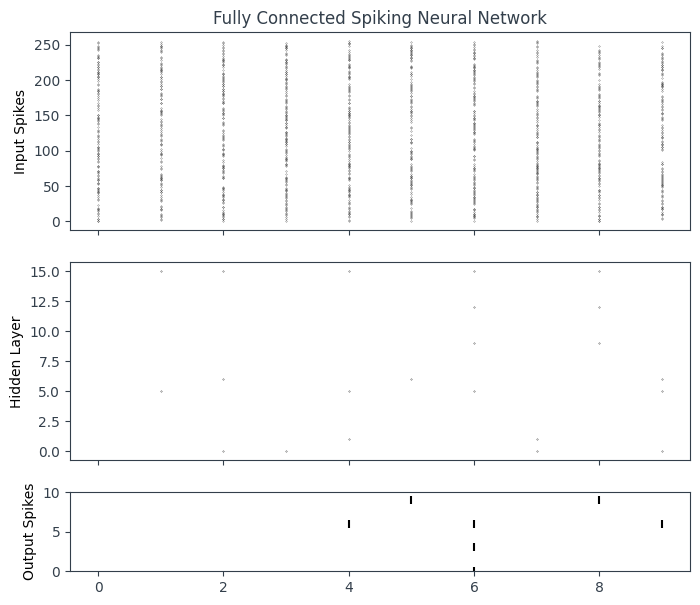

In [75]:
spk1_rec, mem1_rec, spk2_rec, mem2_rec = feedforward_nn.forward(train_spikes[0])

plot_snn_spikes(train_spikes[0], spk1_rec, spk2_rec, "Fully Connected Spiking Neural Network")

In [72]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_inputs = 256
num_hidden = 16
beta = 0.99

model = Autoencoder(num_inputs=num_inputs, num_hidden=num_hidden, beta=beta).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.L1Loss()   # MAE

In [73]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for i in range(train_spikes.size(0)):
        x = train_spikes[i]   # [T, 1, N]

        optimizer.zero_grad()

        spk1_rec, mem1_rec, spk2_rec, mem2_rec = model(x)

        # reconstruct input from output membrane potentials
        loss = criterion(mem2_rec, x)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= train_spikes.size(0)
    print(f"Epoch {epoch+1}/{num_epochs}, MAE loss: {epoch_loss:.4f}")

Epoch 1/10, MAE loss: 0.9153
Epoch 2/10, MAE loss: 0.8752
Epoch 3/10, MAE loss: 0.8435
Epoch 4/10, MAE loss: 0.8244
Epoch 5/10, MAE loss: 0.8187
Epoch 6/10, MAE loss: 0.8132
Epoch 7/10, MAE loss: 0.8098
Epoch 8/10, MAE loss: 0.8060
Epoch 9/10, MAE loss: 0.8023
Epoch 10/10, MAE loss: 0.7968


In [74]:
model.eval()

with torch.no_grad():
    x = train_spikes[0]   # one sample
    spk1_rec, mem1_rec, spk2_rec, mem2_rec = model(x)

    mae = torch.mean(torch.abs(mem2_rec - x)).item()
    print(f"Reconstruction MAE: {mae:.4f}")

Reconstruction MAE: 0.7931
